### meteo.data.gouv.fr SIM2 MENS (SAFRAN) - Génération d'un fichier PARQUET unique par téléchargement/lecture des fichiers CSV de Météo-France par décennie depuis 1958
Génération d'un fichier PARQUET unique représentant un dataframe pour TOUS les paramètres de la france ENTIERE et de l'historique ENTIER depuis 1958
- Ce fichier PARQUET est un dataframe d'une image fidèle des données originales . En option un fichier Excel peut être généré pour des utilisateurs lambdas sans compétence de programmation 
- A partir de ce dataframe pandas, la chaine de traitement des autres scripts effectue une conversion en dataset xarray constituant des rasters géographiques temporels (traitements multi dimentionnels). Cette conversion est montré dans ce notebook à titre d'exemple

datat : https://meteo.data.gouv.fr/<br>
Auteur: [L. Duffar](https://github.com/loicduffar)

####  0. Personalisation / Importation

In [ ]:
# Personalisation / Importation
##################
# Auteur L.Duffar
# Mars 2025
##################

import sys
import os
import datetime
import pandas as pd
import numpy as np
import hvplot.pandas
import requests
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy as cp
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import gzip

################### Personalisation
download_files= True

folder_gz= r"X:\1-COMMUN\DIS\Documentation\Hydrologie\Documentation externe\Climat France\Météo-France\meteo.data\archives\référence\SIM2\M"
folder_csv = r"X:\1-COMMUN\DIS\Documentation\Hydrologie\Documentation externe\Climat France\Météo-France\meteo.data\REFERENCE\SIM2\M"
folder_out= r"X:\1-COMMUN\DIS\Documentation\Hydrologie\Documentation externe\Climat France\Météo-France\SIM2\France"

# Le nom peut contenir le numéro du mois correspondant au dernierfichier CSV LATEST téléchargé (ce fichier LATEST est mis à jour une fois par mois avec les dernières données)
file_parquet= "SIM2 MENS FRANCE 1958_2025 Lamb2.parquet"

################### initialisation
print( datetime.datetime.now().strftime("%Y-%m-%d %H:%M"))

url_files_dict= {
                "MENS_SIM2_1958-1959": "https://www.data.gouv.fr/fr/datasets/r/84b2914d-6e26-48c7-9d63-8e4a0f1c5278",
                "MENS_SIM2_1960-1969": "https://www.data.gouv.fr/fr/datasets/r/26c4034c-b2e4-4b9c-b366-72dfba56610e",
                "MENS_SIM2_1970-1979": "https://www.data.gouv.fr/fr/datasets/r/48afd833-7b78-4db5-8c9c-ae5f619f60f5",
                "MENS_SIM2_1980-1989": "https://www.data.gouv.fr/fr/datasets/r/1847d5c4-10c3-4517-8a89-e5f3b4513fcc",
                "MENS_SIM2_1990-1999": "https://www.data.gouv.fr/fr/datasets/r/414cef46-8754-44bb-ab62-f49965cd6e74",
                "MENS_SIM2_2000-2009": "https://www.data.gouv.fr/fr/datasets/r/e820985b-c5e0-4ea8-b35c-bed99c605aea",
                "MENS_SIM2_2010-2019": "https://www.data.gouv.fr/fr/datasets/r/d6a8fdb8-8c81-4e76-aaa4-f433d16b5550",
                "MENS_SIM2_latest-2020-2025": "https://www.data.gouv.fr/fr/datasets/r/fe2f7d9f-812f-41a4-91d1-6023871c6cf4",
                # "MENS_SIM2_current": "",
                }

# Couches de polygone à partir de fichier GeoJSON en ligne
url_departements= 'https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/departements.geojson'
url_departements= "https://france-geojson.gregoiredavid.fr/repo/regions/provence-alpes-cote-d-azur/departements-provence-alpes-cote-d-azur.geojson"
url_region=       "https://france-geojson.gregoiredavid.fr/repo/regions/provence-alpes-cote-d-azur/region-provence-alpes-cote-d-azur.geojson"

############## Fonctions de téléchargement et décompression
def download_file(url, filename):
    file= os.path.join(folder_gz, filename) + '.csv.gz'
    print('Téléchargement de', filename + '.csv.gz')
    response = requests.get(url)
    if response.status_code == 200:
        with open(file, 'wb') as f:
            f.write(response.content)
    else:
        print("Fichier d'archive non présent à l'url habituelle: ", file)

def decompress_gz(filename):
    file_gz= os.path.join(folder_gz, filename) + '.csv.gz'
    
    if os.path.exists(file_gz):
        with gzip.open(file_gz, 'rb') as f_in:
            file= os.path.join(folder_csv, filename + '.csv') 
            print('Décompression de', filename + '.csv')
            with open(file, 'wb') as f_out:
                # f_out.write(f_in.read()
                f_out.write(f_in.read())
    else:
        print("Fichier d'archive non trouvé: ", file)

print("Terminé")


2025-08-02 13:39
Terminé


#### 1. Lecture des fichiers CSV Météo-France couvrant la France entière depuis 1958 + enregistrement fichier PARQUET
Le fichier parquet contient TOUS les paramètres sur la France ENTIERE depuis 1958 (territoire métropolitain)

In [ ]:
# Lecture des fichiers CSV Météo-France couvrant la France entière depuis 1958 (métropolitaine)

################### initialisation
print( datetime.datetime.now().strftime("%Y-%m-%d %H:%M"))
list_files_CSV= list(url_files_dict.keys())

################## Lecture en ligne des fichiers GeoJSON de zones d'intérêt 
geojson_departements= requests.get(url_departements).json()
geojson_region= requests.get(url_region).json()

################### Téléchargement des fichiers gz
if download_files:
    # Télécharge les fichiers
    for file_csv in list_files_CSV:
        url= url_files_dict[file_csv]
        download_file(url, file_csv)
        decompress_gz(file_csv)

################### Lecture des fichiers
# Extrait des fichiers CSV
# LAMBX;LAMBY;DATE;PRENEI_MENS;PRELIQ_MENS;PRETOTM_MENS;T_MENS;EVAP_MENS;ETP_MENS;PE_MENS;SWI_MENS;DRAINC_MENS;RUNC_MENS;SPI1_MENS;SPI3_MENS;SPI6_MENS;SPI12_MENS;SSWI1_MENS;SSWI3_MENS;SSWI6_MENS;SSWI12_MENS;ECOULEMENT_MENS
# 600;24010;202001;0.0;104.5;104.5;8.9;37.3;18.2;67.2;0.937;56.1;11.5;-0.04;0.90;1.58;1.08;0.30;1.75;2.09;1.55;0.0
# 600;24010;202002;0.0;148.6;148.6;9.6;65.9;27.6;82.7;0.947;55.4;15.7;1.12;0.66;1.49;1.30;0.73;0.99;1.95;1.46;0.0
# 600;24010;202003;0.0;67.1;67.1;8.8;53.0;51.3;14.1;0.927;62.7;7.9;0.30;0.65;1.33;1.23;1.24;0.88;1.87;1.49;0.0
# 600;24010;202004;0.0;67.8;67.8;12.3;56.1;79.2;11.7;0.728;18.1;5.4;0.20;0.84;1.14;1.38;-0.53;0.57;1.54;1.41;0.0
# 600;24010;202005;0.0;22.0;22.0;14.6;81.3;134.6;-59.3;0.676;16.3;1.9;-1.29;-0.62;0.23;1.31;-0.29;0.12;0.77;1.51;0.0

for i, file_SIM2 in enumerate(list_files_CSV):
    print("Lecture de ", file_SIM2 + '.csv')
    df = pd.read_csv(os.path.join(folder_csv, file_SIM2 + '.CSV'), sep=';', decimal='.', 
                     header=0, parse_dates=['DATE'], date_format= '%Y%m', dtype={'LAMBX': int, 'LAMBY': int})
    if i==0:
        df_all= df
    else:
        df_all= pd.concat([df_all, df])

display(df_all)

################### Génère le fichier parquet de df_all 
print('Enregistrement en cours du fichier parquet', file_parquet, 'patientez ...')
df_all.to_parquet(os.path.join(folder_out, file_parquet), index=False)

################### Génère le fichier CSV de df_all OPTIONNEL
file_csv= file_parquet.replace('.parquet', '.csc')
# print('Enregistrement du fichier CSV :', file_csv)
# df_all.to_csv(os.path.join(folder_out, file_csv), sep=';', decimal='.', index=False) # OPTIONNEL car très lourd et long à générer/lire

print('Le fichier parquet est enregistré dans le dossier :', folder_out)

2025-08-02 13:39
Téléchargement de MENS_SIM2_1958-1959.csv.gz
Décompression de MENS_SIM2_1958-1959.csv
Téléchargement de MENS_SIM2_1960-1969.csv.gz
Décompression de MENS_SIM2_1960-1969.csv
Téléchargement de MENS_SIM2_1970-1979.csv.gz
Décompression de MENS_SIM2_1970-1979.csv
Téléchargement de MENS_SIM2_1980-1989.csv.gz
Décompression de MENS_SIM2_1980-1989.csv
Téléchargement de MENS_SIM2_1990-1999.csv.gz
Décompression de MENS_SIM2_1990-1999.csv
Téléchargement de MENS_SIM2_2000-2009.csv.gz
Décompression de MENS_SIM2_2000-2009.csv
Téléchargement de MENS_SIM2_2010-2019.csv.gz
Décompression de MENS_SIM2_2010-2019.csv
Téléchargement de MENS_SIM2_latest-2020-2025.csv.gz
Décompression de MENS_SIM2_latest-2020-2025.csv
Lecture de  MENS_SIM2_1958-1959.csv
Lecture de  MENS_SIM2_1960-1969.csv
Lecture de  MENS_SIM2_1970-1979.csv
Lecture de  MENS_SIM2_1980-1989.csv
Lecture de  MENS_SIM2_1990-1999.csv
Lecture de  MENS_SIM2_2000-2009.csv
Lecture de  MENS_SIM2_2010-2019.csv
Lecture de  MENS_SIM2_latest-

,LAMBX,LAMBY,DATE,PRENEI_MENS,PRELIQ_MENS,PRETOTM_MENS,T_MENS,EVAP_MENS,ETP_MENS,PE_MENS,...,RUNC_MENS,SPI1_MENS,SPI3_MENS,SPI6_MENS,SPI12_MENS,SSWI1_MENS,SSWI3_MENS,SSWI6_MENS,SSWI12_MENS,ECOULEMENT_MENS
0,600,24010,1958-08-01,0.0,101.1,101.1,16.2,58.9,74.1,42.2,...,3.4,1.20,NaN,NaN,NaN,-0.77,NaN,NaN,NaN,0.0
1,600,24010,1958-09-01,0.0,87.4,87.4,16.5,59.7,59.5,27.7,...,4.0,0.82,NaN,NaN,NaN,-0.05,NaN,NaN,NaN,0.0
2,600,24010,1958-10-01,0.0,90.4,90.4,12.4,40.8,35.3,49.6,...,6.9,-0.32,0.82,NaN,NaN,0.69,-0.01,NaN,NaN,0.0
3,600,24010,1958-11-01,0.0,63.8,63.8,9.5,24.9,22.5,38.9,...,5.7,-0.81,-0.38,NaN,NaN,0.36,0.35,NaN,NaN,0.0
4,600,24010,1958-12-01,0.0,114.1,114.1,8.0,38.7,17.1,75.4,...,10.5,-0.15,-0.60,NaN,NaN,-0.25,0.35,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
662759,11960,17450,2025-03-01,0.0,76.5,76.5,11.6,66.3,68.1,10.2,...,7.4,0.35,0.26,0.35,0.06,0.49,0.49,0.15,-1.03,0.0
662760,11960,17450,2025-04-01,0.0,96.9,96.9,14.8,79.2,90.2,17.7,...,11.8,0.56,0.47,0.46,0.34,0.89,0.76,0.51,-0.51,0.0
662761,11960,17450,2025-05-01,0.0,27.9,27.9,17.6,95.6,137.9,-67.7,...,1.0,-0.63,0.18,0.50,0.26,0.27,0.55,0.63,-0.14,0.0
662762,11960,17450,2025-06-01,0.0,1.2,1.2,24.6,48.5,200.0,-47.3,...,0.0,-2.01,-0.39,-0.05,0.16,-0.85,0.27,0.48,0.01,0.0


Enregistrement du fichier parquet : SIM2 MENS FRANCE 1958_2025Z Lamb2.parquet
Le fichier parquet est enregistré dans le dossier : X:\1-COMMUN\DIS\Documentation\Hydrologie\Documentation externe\Climat France\Météo-France\SIM2\France


#### 1bis. Lecture d'un fichier "parquet" pour TOUS les paramètres sur la France ENTIERE depuis 1958 (territoire métropolitain) OPTIONNEL
Le fichier parquet doit avoir été généré au préalable à partir des fichiers CSV Météo-France contenant toutes les mailles de la France et tous les paramètres depuis 1958.
- Le format "parquet" est conçu pour être compact et rapide pour manipuler de grands ensembles de données
- Le fichier "parquet" utilisé ici est une copie conforme d'un dataframe pandas, et il permet de lire rapidement l'historique SIM2 pour la France entière et la totalité des paramètre (dans ce cas 10 s au lieu de 1 minute pour les fichier CSV). Cette caractéristique est notamment précieuse dans la phase de développement qui impose une approche essais-erreurs répétés.


In [2]:
print( datetime.datetime.now().strftime("%Y-%m-%d %H:%M"))
# lire le fichier parquet

df_all= pd.read_parquet(os.path.join(folder_out, file_parquet))
print("Lecture terminée du fichier parquet")
df_all


2025-05-05 19:45
Lecture terminée du fichier parquet


,LAMBX,LAMBY,DATE,PRENEI_MENS,PRELIQ_MENS,PRETOTM_MENS,T_MENS,EVAP_MENS,ETP_MENS,PE_MENS,...,RUNC_MENS,SPI1_MENS,SPI3_MENS,SPI6_MENS,SPI12_MENS,SSWI1_MENS,SSWI3_MENS,SSWI6_MENS,SSWI12_MENS,ECOULEMENT_MENS
0,600,24010,1958-08-01,0.0,101.1,101.1,16.2,58.9,74.1,42.2,...,3.4,1.20,NaN,NaN,NaN,-0.77,NaN,NaN,NaN,0.0
1,600,24010,1958-09-01,0.0,87.4,87.4,16.5,59.7,59.5,27.7,...,4.0,0.82,NaN,NaN,NaN,-0.05,NaN,NaN,NaN,0.0
2,600,24010,1958-10-01,0.0,90.4,90.4,12.4,40.8,35.3,49.6,...,6.9,-0.32,0.82,NaN,NaN,0.69,-0.01,NaN,NaN,0.0
3,600,24010,1958-11-01,0.0,63.8,63.8,9.5,24.9,22.5,38.9,...,5.7,-0.81,-0.38,NaN,NaN,0.36,0.35,NaN,NaN,0.0
4,600,24010,1958-12-01,0.0,114.1,114.1,8.0,38.7,17.1,75.4,...,10.5,-0.15,-0.60,NaN,NaN,-0.25,0.35,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7923487,11960,17450,2024-12-01,0.0,169.0,169.0,9.3,37.8,36.8,131.2,...,29.6,0.94,0.72,0.69,0.17,0.41,0.03,-0.37,-3.67,0.0
7923488,11960,17450,2025-01-01,0.0,63.5,63.5,10.8,34.8,38.3,28.7,...,7.8,-0.08,0.34,0.47,0.16,0.09,0.17,-0.24,-2.30,0.0
7923489,11960,17450,2025-02-01,0.0,63.6,63.6,10.7,37.0,37.5,26.6,...,7.2,0.27,0.61,0.49,0.03,0.56,0.44,-0.04,-1.37,0.0
7923490,11960,17450,2025-03-01,0.0,76.5,76.5,11.6,66.3,68.1,10.2,...,7.4,0.35,0.26,0.35,0.06,0.49,0.49,0.15,-1.03,0.0


#### 2. Conversion des coordonnée Lambert en m OPTIONNEL

In [ ]:
import xarray as xr

print( datetime.datetime.now().strftime("%Y-%m-%d %H:%M"))
# Créer un MultiIndex avec les coordonnées et la date
df_all.set_index(['LAMBX', 'LAMBY', 'DATE'], inplace=True)

ds = xr.Dataset.from_dataframe(df_all)
ds["LAMBX"] = ds["LAMBX"]*100 # conversion en m des coordonnées lambert2 étendues en hm 
ds["LAMBY"] = ds["LAMBY"]*100
print('Le Dataset xarray est le suivant sous sa forme initiale (avant toute transformation):')
display(ds)

2025-07-02 19:16
Le Dataset xarray est le suivant sous sa forme initiale (avant toute transformation):


<xarray.Dataset> Size: 2GB
Dimensions:          (LAMBX: 142, LAMBY: 134, DATE: 803)
Coordinates:
  * LAMBX            (LAMBX) int32 568B 60000 76000 84000 ... 1188000 1196000
  * LAMBY            (LAMBY) int32 536B 1617000 1625000 ... 2673000 2681000
  * DATE             (DATE) datetime64[ns] 6kB 1958-08-01 ... 2025-06-01
Data variables: (12/19)
    PRENEI_MENS      (LAMBX, LAMBY, DATE) float64 122MB nan nan nan ... nan nan
    PRELIQ_MENS      (LAMBX, LAMBY, DATE) float64 122MB nan nan nan ... nan nan
    PRETOTM_MENS     (LAMBX, LAMBY, DATE) float64 122MB nan nan nan ... nan nan
    T_MENS           (LAMBX, LAMBY, DATE) float64 122MB nan nan nan ... nan nan
    EVAP_MENS        (LAMBX, LAMBY, DATE) float64 122MB nan nan nan ... nan nan
    ETP_MENS         (LAMBX, LAMBY, DATE) float64 122MB nan nan nan ... nan nan
    ...               ...
    SPI12_MENS       (LAMBX, LAMBY, DATE) float64 122MB nan nan nan ... nan nan
    SSWI1_MENS       (LAMBX, LAMBY, DATE) float64 122MB nan nan nan ... nan nan
    SSWI3_MENS       (LAMBX, LAMBY, DATE) float64 122MB nan nan nan ... nan nan
    SSWI6_MENS       (LAMBX, LAMBY, DATE) float64 122MB nan nan nan ... nan nan
    SSWI12_MENS      (LAMBX, LAMBY, DATE) float64 122MB nan nan nan ... nan nan
    ECOULEMENT_MENS  (LAMBX, LAMBY, DATE) float64 122MB nan nan nan ... nan nan

#### 3. Conversion du dataset en données spatiale et en WGS84 OPTIONNEL

In [4]:
import rioxarray

print(datetime.datetime.now().strftime('%d/%m/%Y %H:%M'))
ds_spatial = ds.copy()
# inscrit le CRS dans les attributs du dataset
ds_spatial = ds_spatial.rio.write_crs("IGNF:LAMBE", inplace=True)
# Définir explicitement les dimensions spatiales qui sont nommées impérativement 'x' et 'y' comme exigé par la méthode rioxarray.rio.set_spatial_dims()
ds_spatial = ds_spatial.rename({"LAMBX": "x", "LAMBY": "y"})
ds_spatial = ds_spatial.rio.set_spatial_dims(x_dim='x', y_dim='y', inplace= True)

ds_spatial

# ds_lonlat= ds_spatial.rio.write_nodata(-9999, inplace=True)# Définir explicitement la valeur nodata avant la reprojection qui ne sais pas gérer les NaN
# ds_latlon= ds_spatial.fillna(-9999) # Définir explicitement la valeur nodata avant la reprojection qui ne sais pas gérer les NaN
#======== Initialisation

# seuil de filtrage des valeurs élevées générées par la reprojection à la place de NaN
seuil_filtre= 1e+10

#======== Traitement
# déplacement de la latitude en première dimension spatiale, comme exigé par la fonction rioxarray.rio.reproject()
ds_latlon = ds_spatial.transpose('DATE', 'y', 'x')
display(ds_latlon)
# reprojection en latlon
ds_latlon = ds_latlon.rio.reproject("EPSG:4326")
# remplace par NaN les valeurs supérieures trés élevées générées par la méthode rioxarray.rio.reproject qui ne gère pas correctement les NaN
ds_latlon = ds_latlon.where(ds_latlon < seuil_filtre, other= float('nan'))

print ("AVERTISSEMENT: la reprojection produit inévitablement une interpolation entre les valeurs intiales SAFRAN. IL FAUDRA ETRE ATTENTIF A D'EVENTUELLES VALEURS ABERRANTES OU FAUSSEES")
print("Par exemple on constate déjà que les valeurs maximales de précipitations et de chute de neige sont plus faibles de 4% (maximum qui concernent probablement un nombre réduit de mailles).")

ds_latlon

02/07/2025 19:16


<xarray.Dataset> Size: 2GB
Dimensions:          (x: 142, y: 134, DATE: 803)
Coordinates:
  * x                (x) int32 568B 60000 76000 84000 ... 1188000 1196000
  * y                (y) int32 536B 1617000 1625000 1633000 ... 2673000 2681000
  * DATE             (DATE) datetime64[ns] 6kB 1958-08-01 ... 2025-06-01
    spatial_ref      int32 4B 0
Data variables: (12/19)
    PRENEI_MENS      (DATE, y, x) float64 122MB nan nan nan nan ... nan nan nan
    PRELIQ_MENS      (DATE, y, x) float64 122MB nan nan nan nan ... nan nan nan
    PRETOTM_MENS     (DATE, y, x) float64 122MB nan nan nan nan ... nan nan nan
    T_MENS           (DATE, y, x) float64 122MB nan nan nan nan ... nan nan nan
    EVAP_MENS        (DATE, y, x) float64 122MB nan nan nan nan ... nan nan nan
    ETP_MENS         (DATE, y, x) float64 122MB nan nan nan nan ... nan nan nan
    ...               ...
    SPI12_MENS       (DATE, y, x) float64 122MB nan nan nan nan ... nan nan nan
    SSWI1_MENS       (DATE, y, x) float64 122MB nan nan nan nan ... nan nan nan
    SSWI3_MENS       (DATE, y, x) float64 122MB nan nan nan nan ... nan nan nan
    SSWI6_MENS       (DATE, y, x) float64 122MB nan nan nan nan ... nan nan nan
    SSWI12_MENS      (DATE, y, x) float64 122MB nan nan nan nan ... nan nan nan
    ECOULEMENT_MENS  (DATE, y, x) float64 122MB nan nan nan nan ... nan nan nan

AVERTISSEMENT: la reprojection produit inévitablement une interpolation entre les valeurs intiales SAFRAN. IL FAUDRA ETRE ATTENTIF A D'EVENTUELLES VALEURS ABERRANTES OU FAUSSEES
Par exemple on constate déjà que les valeurs maximales de précipitations et de chute de neige sont plus faibles de 4% (maximum qui concernent probablement un nombre réduit de mailles).


<xarray.Dataset> Size: 2GB
Dimensions:          (DATE: 803, y: 109, x: 179)
Coordinates:
  * x                (x) float64 1kB -5.347 -5.256 -5.166 ... 10.63 10.72 10.81
  * y                (y) float64 872B 51.11 51.02 50.93 ... 41.49 41.4 41.31
  * DATE             (DATE) datetime64[ns] 6kB 1958-08-01 ... 2025-06-01
    spatial_ref      int32 4B 0
Data variables: (12/19)
    PRENEI_MENS      (DATE, y, x) float64 125MB nan nan nan nan ... nan nan nan
    PRELIQ_MENS      (DATE, y, x) float64 125MB nan nan nan nan ... nan nan nan
    PRETOTM_MENS     (DATE, y, x) float64 125MB nan nan nan nan ... nan nan nan
    T_MENS           (DATE, y, x) float64 125MB nan nan nan nan ... nan nan nan
    EVAP_MENS        (DATE, y, x) float64 125MB nan nan nan nan ... nan nan nan
    ETP_MENS         (DATE, y, x) float64 125MB nan nan nan nan ... nan nan nan
    ...               ...
    SPI12_MENS       (DATE, y, x) float64 125MB nan nan nan nan ... nan nan nan
    SSWI1_MENS       (DATE, y, x) float64 125MB nan nan nan nan ... nan nan nan
    SSWI3_MENS       (DATE, y, x) float64 125MB nan nan nan nan ... nan nan nan
    SSWI6_MENS       (DATE, y, x) float64 125MB nan nan nan nan ... nan nan nan
    SSWI12_MENS      (DATE, y, x) float64 125MB nan nan nan nan ... nan nan nan
    ECOULEMENT_MENS  (DATE, y, x) float64 125MB nan nan nan nan ... nan nan nan

#### 4. Clip sur le secteur (région PACA en l'occurence) OPTIONNEL POUR CONTROLE VISUEL

02/07/2025 19:17


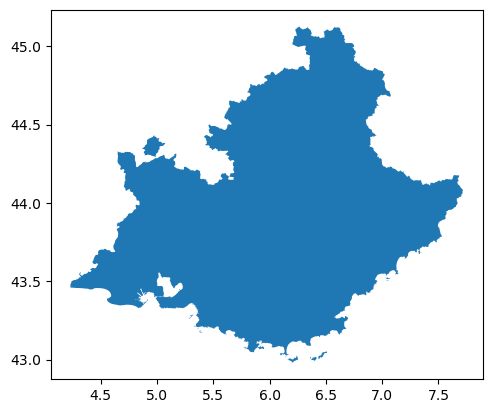

,id,code,NOM,geometry
0,93,93,Provence-Alpes-Côte d'Azur,"MULTIPOLYGON (((6.25870 42.99672, 6.25865 42.9..."


<xarray.Dataset> Size: 102MB
Dimensions:          (DATE: 803, y: 22, x: 38)
Coordinates:
  * x                (x) float64 304B 4.273 4.364 4.455 ... 7.45 7.541 7.631
  * y                (y) float64 176B 45.03 44.94 44.85 ... 43.31 43.22 43.12
  * DATE             (DATE) datetime64[ns] 6kB 1958-08-01 ... 2025-06-01
    spatial_ref      int32 4B 0
Data variables: (12/19)
    PRENEI_MENS      (DATE, y, x) float64 5MB nan nan nan nan ... nan nan nan
    PRELIQ_MENS      (DATE, y, x) float64 5MB nan nan nan nan ... nan nan nan
    PRETOTM_MENS     (DATE, y, x) float64 5MB nan nan nan nan ... nan nan nan
    T_MENS           (DATE, y, x) float64 5MB nan nan nan nan ... nan nan nan
    EVAP_MENS        (DATE, y, x) float64 5MB nan nan nan nan ... nan nan nan
    ETP_MENS         (DATE, y, x) float64 5MB nan nan nan nan ... nan nan nan
    ...               ...
    SPI12_MENS       (DATE, y, x) float64 5MB nan nan nan nan ... nan nan nan
    SSWI1_MENS       (DATE, y, x) float64 5MB nan nan nan nan ... nan nan nan
    SSWI3_MENS       (DATE, y, x) float64 5MB nan nan nan nan ... nan nan nan
    SSWI6_MENS       (DATE, y, x) float64 5MB nan nan nan nan ... nan nan nan
    SSWI12_MENS      (DATE, y, x) float64 5MB nan nan nan nan ... nan nan nan
    ECOULEMENT_MENS  (DATE, y, x) float64 5MB nan nan nan nan ... nan nan nan

In [5]:
from shapely.geometry import mapping
import rioxarray

#======== Initialisation
print(datetime.datetime.now().strftime('%d/%m/%Y %H:%M'))
# seuil de filtrage des valeurs élevées générées par la reprojection à la place de NaN
seuil_filtre= 1e+10

#======== Traitement
file_polygones= r"X:\1-COMMUN\DIS\Documentation\Hydrologie\Documentation externe\Climat France\Météo-France\SIM2\PACA\shp\Départements PACA.shp"
file_polygones= r"X:\1-COMMUN\DIS\Documentation\Hydrologie\Documentation externe\Climat France\Météo-France\SIM2\PACA\shp\Région PACA_WGS84.gpkg"
# nom de la colonne du fichier SHP qui contient l'IDENTIFIANT de polygone voulu pour les cartes (utile pour nommer les polygones dans le datframe en sortie)
# nom_champ_polygone = 'code'
nom_champ_polygone = 'nom'
# Nouveau nom de COLONE IDENTIFIANT de polygone dans le geodataframe tiré du fichier SHP
# nom_colonne_polygone = 'DEPARTEMENT'
nom_colonne_polygone = 'NOM'

gdf = gpd.read_file(file_polygones)
# renomme la colonne des identifiants de polygones # utile pour nommer les polygones dans le datframe en sortie
gdf.rename(columns={ nom_champ_polygone: nom_colonne_polygone}, inplace=True)
gdf.plot()
plt.show()
display(gdf)

#   Clipping des mailles contenues dans le polygone https://corteva.github.io/rioxarray/html/rioxarray.html 
#       'invert= False' (défaut) pour conserver les mailles qui sont dans le polygone (et non l'inverse)
#       'drop= True' If True, drop the data outside of the extent of the mask geoemtries Otherwise, it will return the same raster with the data masked (avec des NaN ?). Default is True.
#       'all_touched= False' (default)  If false, only pixels whose center is within the polygon or that are selected by Bresenham’s line algorithm will be burned in. If True, all pixels touched by geometries will be burned in. 
#       'from_disk=True' (lazy loading) pour économiser la mémoire si nécessaire. Ainsi l'objet généré par clip() n'est effectivement calculé que quand nécessaire par la suite

# ds_clipped = ds_latlon.rio.clip(gdf.geometry.apply(mapping), gdf.crs)
# ds_clipped = ds_latlon.rio.clip(geometries= [polygone], crs=4326, invert= False, drop= True, all_touched= False, from_disk= True) 
ds_clipped = ds_latlon.rio.clip(geometries= gdf['geometry'], crs=4326, invert= False, drop= True, all_touched= False, from_disk= True) 
#   remplace par NaN les valeurs trés élevées générées par la méthode rioxarray.rio.reproject qui ne gère pas correctement les NaN
ds_clipped = ds_clipped.where(ds_clipped < seuil_filtre, other= float('nan'))
ds_clipped


#### 5. Carte d'une date choisie OPTIONNEL POUR CONTROL VISUEL

02/07/2025 19:17


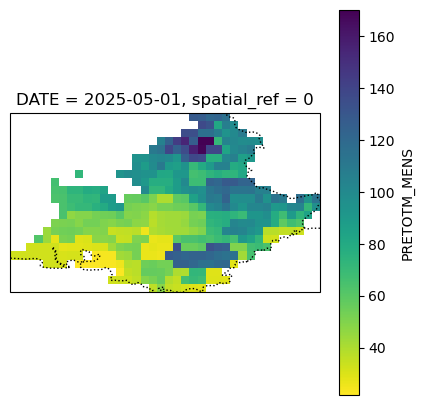

In [6]:
################### Personalisation
date_to_plot= '2025-05-01' # date à afficher sur la carte

################### Carte
print(datetime.datetime.now().strftime('%d/%m/%Y %H:%M'))
# trace ds_clipped en carte cartopy
fig = plt.figure(figsize=(5, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
data= ds_clipped['PRETOTM_MENS'].sel(DATE= date_to_plot).squeeze()
data.plot(ax= ax, transform= ccrs.PlateCarree(), cmap='viridis_r', add_colorbar=True)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE, linestyle=':')
# ax.add_feature(cfeature.LAND, facecolor='lightgray')

plt.show()